# 03 - ExtraTrees Modeling Pipeline with Controlled Validation

## Objective

This notebook builds the first robust forward-prediction baseline for the Boom Challenge.

The goal is not final optimization yet. The goal is to verify whether a physics-informed ExtraTrees pipeline can provide a reliable baseline before testing more advanced strategies.

Main questions:

- Do engineered physics features improve prediction quality compared with raw inputs?
- Should all targets use the same feature set, or should feature sets be selected by target?
- Are distance targets more difficult in low-gravity regimes?
- Is the model reliable near the inverse-design constraint zone?

## Pipeline Architecture

The modeling workflow used in this notebook is:

```text
Raw input data
    ↓
Physics-inspired feature engineering
    ↓
Target-specific feature set selection
    ↓
Sklearn pipeline
    ├── ColumnTransformer: keeps only selected features
    └── ExtraTreesRegressor: robust tree-based regressor
    ↓
KFold cross-validation
    ↓
OOF predictions and error analysis
    ↓
Best feature set selected per target
```

The pipeline is intentionally simple and readable. Feature engineering is done once before modeling, then `make_pipeline` and `ColumnTransformer` are used to build a clean model pipeline for each target.

In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
INVERSE_DIR = PROJECT_ROOT / "data" / "raw" / "inverse_design"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
REPORTS_DIR = PROJECT_ROOT / "reports"

for path in [PROCESSED_DIR, SUBMISSIONS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data:", FORWARD_DIR)
print("Inverse design:", INVERSE_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Inverse design: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design


## 1. Load Data and Constraints

The forward dataset contains impact parameters and ejecta outcomes. The inverse-design constraint file is loaded only to evaluate whether the model behaves reasonably near the target zone.

In [3]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor",
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize",
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
raw_test = pd.read_csv(FORWARD_DIR / "test.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]
submission_template = pd.read_csv(FORWARD_DIR / "prediction_submission_template.csv")

constraints_path = INVERSE_DIR / "constraints.json"
if not constraints_path.exists():
    constraints_path = PROJECT_ROOT / "constraints.json"

with open(constraints_path, "r") as f:
    constraints_data = json.load(f)

output_constraints = constraints_data["constraints"]
input_bounds = constraints_data["input_bounds"]

print("Raw train:", raw_train.shape)
print("Raw test:", raw_test.shape)
print("Targets:", y.shape)
print("Output constraints:")
display(pd.DataFrame([output_constraints]))

display(raw_train.head())
display(y.head())

Raw train: (2930, 8)
Raw test: (492, 8)
Targets: (2930, 6)
Output constraints:


,p80_min,p80_max,r95_max
0,96.0,101.0,175.0


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,76.972350,0.184728,0.016671,198.938699,175.527939,76.235779
1,269.057465,0.000622,0.916734,239.268477,447.157838,141.894047
2,104.070923,0.070343,0.094438,192.986417,189.286407,84.235774
3,257.618403,0.001026,0.880122,289.289693,500.000028,169.866473
4,111.717167,0.058576,0.136166,94.229304,97.614864,42.928393


## 2. Physics-Inspired Feature Engineering

The EDA showed two important target families:

- fragmentation targets depend strongly on transferred energy, material strength, porosity, and regime behavior;
- distance targets depend strongly on gravity, horizontal energy, and drag-related effects.

The features below are not exact physical equations. They are physics-inspired proxies designed to help the model learn meaningful interactions.

In [4]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    eps = 1e-9

    # Energy transfer
    X["effective_energy"] = X["energy"] * X["coupling"]
    X["log_energy"] = np.log1p(X["energy"])
    X["log_effective_energy"] = np.log1p(X["effective_energy"])

    # Angle decomposition
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]

    # Material resistance and fragmentation proxies
    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
    X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
    X["coupling_porosity"] = X["coupling"] * X["porosity"]
    X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
    X["porosity_strength"] = X["porosity"] * X["strength"]

    # Gravity-scaled distance proxies
    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
    X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
    X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

    # Atmosphere and drag proxies
    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
    X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

    # Pi-like scaling proxies
    X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
    X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
    X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

    # Regime indicators from EDA
    X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
    X["strength_regime"] = (X["strength"] > 2.6).astype(int)
    X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
    X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)
    X["regime_combo"] = (
        X["porosity_regime"] * 8
        + X["strength_regime"] * 4
        + X["angle_regime"] * 2
        + X["atm_regime"]
    )

    # Additional interaction proxies
    X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
    X["fragility"] = X["porosity"] / (X["strength"] + eps)
    X["range_proxy"] = (X["effective_energy"] * X["cos_angle"] ** 2) / (X["gravity"] * X["strength"] + eps)
    X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
    X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]

    # Controlled ratio for near-zero atmosphere
    X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
    X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])
    X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

    return X

X_fe_train = add_physics_features(raw_train)
X_fe_test = add_physics_features(raw_test)

print("Engineered train:", X_fe_train.shape)
print("Engineered test:", X_fe_test.shape)

Engineered train: (2930, 46)
Engineered test: (492, 46)


## 3. Basic Feature Matrix Checks

Before modeling, the engineered train and test matrices must have the same columns and contain no missing or infinite values.

In [5]:
def check_modeling_matrix(X: pd.DataFrame, name: str) -> None:
    numeric = X.select_dtypes(include=[np.number])
    print(f"{name}")
    print("Shape:", X.shape)
    print("Missing values:", int(X.isna().sum().sum()))
    print("Infinite values:", int(np.isinf(numeric).sum().sum()))
    print("Non-numeric columns:", [c for c in X.columns if c not in numeric.columns])

check_modeling_matrix(X_fe_train, "X_fe_train")
check_modeling_matrix(X_fe_test, "X_fe_test")

assert X_fe_train.shape[0] == y.shape[0]
assert X_fe_train.columns.tolist() == X_fe_test.columns.tolist()

X_fe_train
Shape: (2930, 46)
Missing values: 0
Infinite values: 0
Non-numeric columns: []
X_fe_test
Shape: (492, 46)
Missing values: 0
Infinite values: 0
Non-numeric columns: []


## 4. Feature Sets

Multiple feature sets are compared. The goal is to check whether physics-informed features improve performance and whether different target families need different inputs.

In [6]:
raw_features = input_cols.copy()

core_physics_features = raw_features + [
    "effective_energy", "log_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
]

extended_plus_regimes = core_physics_features + [
    "pi_gravity_proxy", "pi_strength_proxy", "pi_atmosphere_proxy",
    "scaled_energy", "fragility", "range_proxy", "energy_sin_angle", "momentum_proxy",
    "coupling_per_atm_clipped", "log_coupling_per_atm", "retention_factor",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

fragmentation_features = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "drag_proxy", "atmosphere_shape_energy",
    "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy", "fragility",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

distance_features = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
    "pi_gravity_proxy", "pi_atmosphere_proxy", "scaled_energy", "range_proxy",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

def clean_feature_list(features, X):
    seen = set()
    out = []
    for f in features:
        if f in X.columns and f not in seen:
            out.append(f)
            seen.add(f)
    return out

feature_sets = {
    "raw": clean_feature_list(raw_features, X_fe_train),
    "core_physics": clean_feature_list(core_physics_features, X_fe_train),
    "extended_plus_regimes": clean_feature_list(extended_plus_regimes, X_fe_train),
    "target_family_specific": None,  # handled by selector function
}

fragmentation_features = clean_feature_list(fragmentation_features, X_fe_train)
distance_features = clean_feature_list(distance_features, X_fe_train)

feature_set_summary = pd.DataFrame([
    {"feature_set": name, "n_features": len(cols) if cols is not None else "target-dependent"}
    for name, cols in feature_sets.items()
])

display(feature_set_summary)
print("Fragmentation-specific features:", len(fragmentation_features))
print("Distance-specific features:", len(distance_features))

,feature_set,n_features
0,raw,8
1,core_physics,30
2,extended_plus_regimes,46
3,target_family_specific,target-dependent


Fragmentation-specific features: 34
Distance-specific features: 33


## 5. Sklearn Pipeline Definition

Each target is trained using a simple sklearn pipeline:

```text
ColumnTransformer
    ↓ selects only the feature set for the current target
ExtraTreesRegressor
    ↓ predicts one target
```

ExtraTrees was selected as a robust tabular baseline because it handles non-linear relationships, threshold effects, and feature interactions well.

In [7]:
def clip_predictions(preds: np.ndarray, target: str) -> np.ndarray:
    preds = np.asarray(preds).copy()
    if target in ["fines_frac", "oversize_frac"]:
        preds = np.clip(preds, 0, 1)
    else:
        preds = np.clip(preds, 0, None)
    return preds


def regression_metrics(y_true, y_pred, target_name=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    out = {"MAE": mae, "RMSE": rmse, "R2": r2}
    if target_name is not None:
        out["normalized_MAE"] = mae / (y[target_name].std() + 1e-9)
    return out


def build_extratrees_pipeline(features, random_state=42):
    feature_selector = ColumnTransformer(
        transformers=[("selected_features", "passthrough", features)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    model = ExtraTreesRegressor(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )

    return make_pipeline(feature_selector, model)

# Visual summary of the model pipeline
print("Pipeline architecture:")
print("Raw / engineered feature matrix")
print("  -> ColumnTransformer(selected_features)")
print("  -> ExtraTreesRegressor")
print("  -> clipped prediction")

Pipeline architecture:
Raw / engineered feature matrix
  -> ColumnTransformer(selected_features)
  -> ExtraTreesRegressor
  -> clipped prediction


## 6. Cross-Validation Functions

The notebook uses 5-fold cross-validation and stores out-of-fold predictions. OOF predictions are useful because every training row is predicted by a model that did not train on that row.

In [8]:
def get_features_for_target(feature_set_name, target):
    if feature_set_name == "target_family_specific":
        if target in fragmentation_targets:
            return fragmentation_features
        return distance_features
    return feature_sets[feature_set_name]


def cross_validate_target(
    X: pd.DataFrame,
    y_df: pd.DataFrame,
    target: str,
    feature_set_name: str,
    n_splits: int = 5,
    random_state: int = 42,
):
    features = get_features_for_target(feature_set_name, target)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_pred = np.zeros(len(y_df))
    fold_rows = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):
        model = build_extratrees_pipeline(features, random_state=random_state + fold)

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y_df.iloc[train_idx][target], y_df.iloc[valid_idx][target]

        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        pred = clip_predictions(pred, target)
        oof_pred[valid_idx] = pred

        row = regression_metrics(y_valid, pred, target_name=target)
        row.update({"fold": fold, "target": target, "feature_set": feature_set_name, "n_features": len(features)})
        fold_rows.append(row)

    overall = regression_metrics(y_df[target], oof_pred, target_name=target)
    overall.update({"target": target, "feature_set": feature_set_name, "n_features": len(features)})

    return pd.DataFrame(fold_rows), overall, oof_pred


def evaluate_feature_set(feature_set_name):
    all_fold_rows = []
    all_overall_rows = []
    oof_predictions = pd.DataFrame(index=y.index)

    for target in target_cols:
        fold_df, overall_row, oof_pred = cross_validate_target(
            X_fe_train, y, target, feature_set_name
        )
        all_fold_rows.append(fold_df)
        all_overall_rows.append(overall_row)
        oof_predictions[target] = oof_pred

    return pd.DataFrame(all_overall_rows), pd.concat(all_fold_rows, ignore_index=True), oof_predictions

## 7. Evaluate Feature Sets

We compare a small number of feature sets to avoid overcomplicating the first modeling baseline.

In [9]:
results_map = {}
fold_results_map = {}
oof_map = {}

for feature_set_name in feature_sets.keys():
    print(f"Evaluating: {feature_set_name}")
    overall_results, fold_results, oof_predictions = evaluate_feature_set(feature_set_name)
    results_map[feature_set_name] = overall_results
    fold_results_map[feature_set_name] = fold_results
    oof_map[feature_set_name] = oof_predictions

comparison_results = pd.concat(results_map.values(), ignore_index=True)

# Compact comparison: only the best rows per target are shown later.
display(comparison_results.sort_values(["target", "normalized_MAE"]))

Evaluating: raw


Evaluating: core_physics
Evaluating: extended_plus_regimes
Evaluating: target_family_specific


,MAE,RMSE,R2,normalized_MAE,target,feature_set,n_features
18,7.711179,10.257217,0.975659,0.117271,P80,target_family_specific,34
6,7.730082,10.273639,0.975581,0.117558,P80,core_physics,30
12,7.783507,10.352469,0.975204,0.118371,P80,extended_plus_regimes,46
0,9.879243,12.858965,0.961744,0.150243,P80,raw,8
10,50.245198,78.352377,0.899257,0.203505,R50_fines,core_physics,30
16,50.257977,78.354081,0.899253,0.203557,R50_fines,extended_plus_regimes,46
22,50.329516,78.446782,0.899014,0.203847,R50_fines,target_family_specific,33
4,54.725985,83.167394,0.886495,0.221654,R50_fines,raw,8
17,22.580781,38.485285,0.873996,0.208239,R50_oversize,extended_plus_regimes,46
11,22.588227,38.471501,0.874087,0.208307,R50_oversize,core_physics,30


## 8. Select Best Feature Set Per Target

The model is selected separately for each target using normalized MAE. This prevents large-scale targets from dominating the decision.

In [10]:
best_rows = (
    comparison_results
    .sort_values(["target", "normalized_MAE"])
    .groupby("target", as_index=False)
    .first()
)

best_feature_set_by_target = dict(zip(best_rows["target"], best_rows["feature_set"]))

print("Best feature set by target:")
display(best_rows[["target", "feature_set", "MAE", "RMSE", "R2", "normalized_MAE", "n_features"]])
print(best_feature_set_by_target)

best_rows.to_csv(REPORTS_DIR / "extratrees_best_feature_set_by_target.csv", index=False)

Best feature set by target:


,target,feature_set,MAE,RMSE,R2,normalized_MAE,n_features
0,P80,target_family_specific,7.711179,10.257217,0.975659,0.117271,34
1,R50_fines,core_physics,50.245198,78.352377,0.899257,0.203505,30
2,R50_oversize,extended_plus_regimes,22.580781,38.485285,0.873996,0.208239,46
3,R95,extended_plus_regimes,40.414064,66.886848,0.921350,0.169420,46
4,fines_frac,target_family_specific,0.006487,0.014240,0.956900,0.094558,34
5,oversize_frac,target_family_specific,0.026200,0.035832,0.990204,0.072357,34


{'P80': 'target_family_specific', 'R50_fines': 'core_physics', 'R50_oversize': 'extended_plus_regimes', 'R95': 'extended_plus_regimes', 'fines_frac': 'target_family_specific', 'oversize_frac': 'target_family_specific'}


### Feature-set selection insight

The feature-set comparison checks whether one global feature set is sufficient for all targets. The expected behavior is that fragmentation targets prefer material and energy-transfer features, while distance targets prefer gravity-scaled and range-related features.

This step justifies using target-specific configurations in later notebooks.

## 9. Build Selected OOF Predictions

For each target, we take the OOF predictions from the feature set selected for that target. This gives one consolidated validation prediction table.

In [11]:
selected_oof = pd.DataFrame(index=y.index)

for target in target_cols:
    best_set = best_feature_set_by_target[target]
    selected_oof[target] = oof_map[best_set][target]

selected_metrics = []
for target in target_cols:
    metrics = regression_metrics(y[target], selected_oof[target], target_name=target)
    metrics["target"] = target
    metrics["selected_feature_set"] = best_feature_set_by_target[target]
    selected_metrics.append(metrics)

selected_metrics_df = pd.DataFrame(selected_metrics)
display(selected_metrics_df.sort_values("normalized_MAE"))

selected_oof.to_csv(REPORTS_DIR / "extratrees_selected_oof_predictions.csv", index=False)
selected_metrics_df.to_csv(REPORTS_DIR / "extratrees_selected_metrics.csv", index=False)

,MAE,RMSE,R2,normalized_MAE,target,selected_feature_set
2,0.026200,0.035832,0.990204,0.072357,oversize_frac,target_family_specific
1,0.006487,0.014240,0.956900,0.094558,fines_frac,target_family_specific
0,7.711179,10.257217,0.975659,0.117271,P80,target_family_specific
3,40.414064,66.886848,0.921350,0.169420,R95,extended_plus_regimes
4,50.245198,78.352377,0.899257,0.203505,R50_fines,core_physics
5,22.580781,38.485285,0.873996,0.208239,R50_oversize,extended_plus_regimes


## 10. Error Summary

We summarize average error, upper-tail error, and bias. P95 absolute error is important because distance targets contain rare but large errors.

In [12]:
error_rows = []

for target in target_cols:
    residual = selected_oof[target] - y[target]
    abs_error = residual.abs()
    error_rows.append({
        "target": target,
        "selected_feature_set": best_feature_set_by_target[target],
        "MAE": abs_error.mean(),
        "Median_AE": abs_error.median(),
        "P90_AE": np.percentile(abs_error, 90),
        "P95_AE": np.percentile(abs_error, 95),
        "Bias_mean_residual": residual.mean(),
        "R2": r2_score(y[target], selected_oof[target]),
    })

error_summary_df = pd.DataFrame(error_rows)
display(error_summary_df)
error_summary_df.to_csv(REPORTS_DIR / "extratrees_error_summary.csv", index=False)

,target,selected_feature_set,MAE,Median_AE,P90_AE,P95_AE,Bias_mean_residual,R2
0,P80,target_family_specific,7.711179,5.946852,16.858204,21.748532,-0.008502,0.975659
1,fines_frac,target_family_specific,0.006487,0.000635,0.019544,0.031649,-0.000066,0.956900
2,oversize_frac,target_family_specific,0.026200,0.019166,0.058831,0.075833,-0.000101,0.990204
3,R95,extended_plus_regimes,40.414064,20.672280,102.331399,148.519727,-0.246611,0.921350
4,R50_fines,core_physics,50.245198,27.101563,128.141525,174.100330,-0.283074,0.899257
5,R50_oversize,extended_plus_regimes,22.580781,11.495468,55.366306,81.443275,-0.016829,0.873996


## 11. Predicted vs True Checks

Only a few representative plots are shown to keep the notebook readable.

- P80 represents size prediction.
- R95 represents distance prediction.
- oversize_frac represents a fractional target with strong regime behavior.

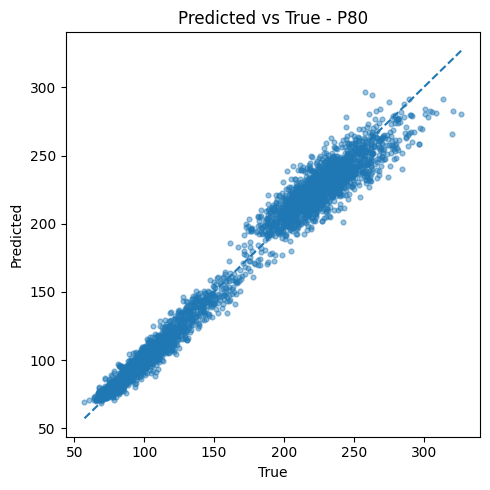

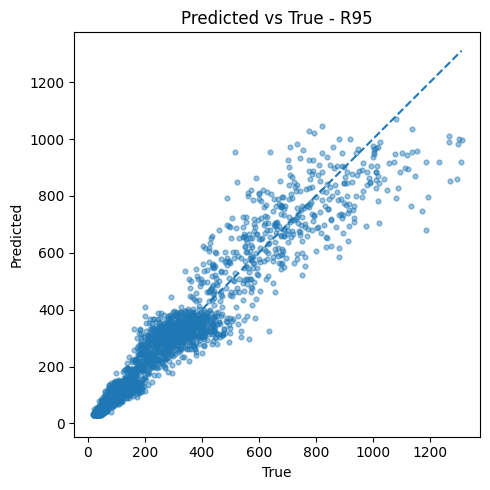

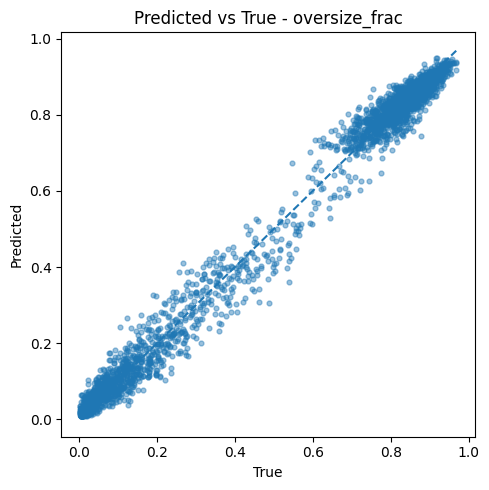

In [13]:
plot_targets = ["P80", "R95", "oversize_frac"]

for target in plot_targets:
    plt.figure(figsize=(5, 5))
    plt.scatter(y[target], selected_oof[target], alpha=0.45, s=12)
    min_val = min(y[target].min(), selected_oof[target].min())
    max_val = max(y[target].max(), selected_oof[target].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.title(f"Predicted vs True - {target}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

## 12. Gravity-Regime Error Analysis

Gravity is the main driver for distance targets. We check whether distance errors remain stable across gravity levels.

,gravity,n,MAE,Median_AE,true_mean,pred_mean,relative_MAE,target
0,1.62,990,79.538458,62.560933,504.102546,501.916227,0.157782,R95
1,3.71,1000,30.098760,23.005266,186.685165,187.774066,0.161227,R95
2,9.81,940,10.182313,7.363774,59.900523,60.276036,0.169987,R95
3,1.62,990,99.020545,84.576483,617.765891,615.792948,0.160288,R50_fines
4,3.71,1000,37.482401,30.741132,231.088286,231.816231,0.162199,R50_fines
5,9.81,940,12.452862,10.441833,72.569602,72.990731,0.171599,R50_fines
6,1.62,990,44.581109,33.971505,251.674665,250.968546,0.177138,R50_oversize
7,3.71,1000,16.715546,12.823293,92.754582,93.221150,0.180213,R50_oversize
8,9.81,940,5.649834,4.170506,29.572605,29.767478,0.191050,R50_oversize


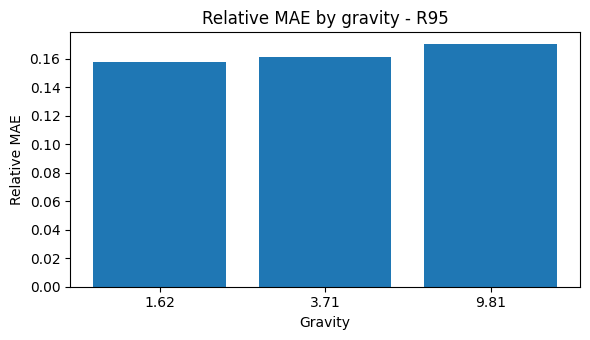

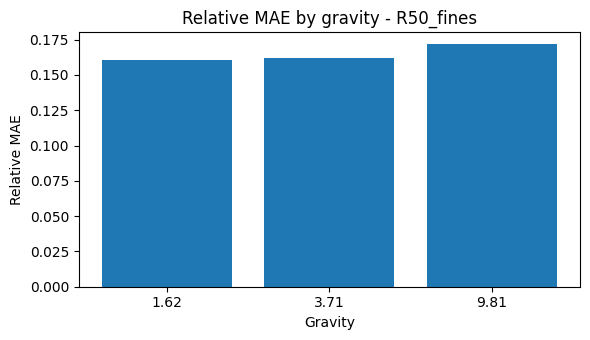

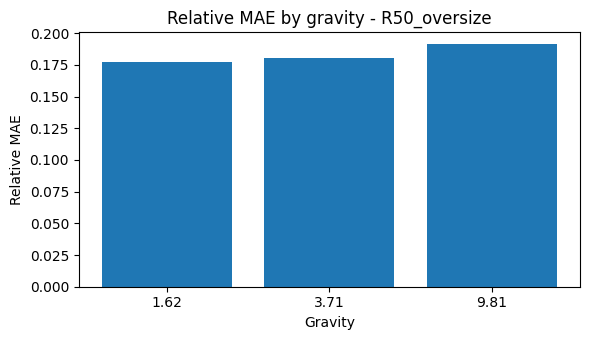

In [14]:
gravity_error_rows = []

for target in distance_targets:
    abs_error = (selected_oof[target] - y[target]).abs()
    temp = pd.DataFrame({
        "gravity": raw_train["gravity"],
        "target": target,
        "abs_error": abs_error,
        "true_value": y[target],
        "prediction": selected_oof[target],
    })

    grouped = (
        temp.groupby("gravity")
        .agg(
            n=("abs_error", "size"),
            MAE=("abs_error", "mean"),
            Median_AE=("abs_error", "median"),
            true_mean=("true_value", "mean"),
            pred_mean=("prediction", "mean"),
        )
        .reset_index()
    )
    grouped["relative_MAE"] = grouped["MAE"] / (grouped["true_mean"].abs() + 1e-9)
    grouped["target"] = target
    gravity_error_rows.append(grouped)

gravity_error_df = pd.concat(gravity_error_rows, ignore_index=True)
display(gravity_error_df)
gravity_error_df.to_csv(REPORTS_DIR / "extratrees_error_by_gravity.csv", index=False)

for target in distance_targets:
    temp = gravity_error_df[gravity_error_df["target"] == target]
    plt.figure(figsize=(6, 3.5))
    plt.bar(temp["gravity"].astype(str), temp["relative_MAE"])
    plt.title(f"Relative MAE by gravity - {target}")
    plt.xlabel("Gravity")
    plt.ylabel("Relative MAE")
    plt.tight_layout()
    plt.show()

### Gravity-regime insight

Absolute errors are naturally larger in low-gravity regimes because the true travel distances are larger. Relative MAE is more stable across gravity levels, which suggests that the model captures the main gravity-distance pattern but still needs careful evaluation for extreme distance cases.

## 13. Constraint-Zone Check

The inverse-design objective is:

```text
96 <= P80 <= 101
R95 <= 175
```

This check evaluates how well the OOF predictions identify rows near the inverse-design target zone in the training data.

In [15]:
p80_min = output_constraints["p80_min"]
p80_max = output_constraints["p80_max"]
r95_max = output_constraints["r95_max"]

true_feasible = y["P80"].between(p80_min, p80_max) & (y["R95"] <= r95_max)
pred_feasible = selected_oof["P80"].between(p80_min, p80_max) & (selected_oof["R95"] <= r95_max)

constraint_eval = pd.DataFrame({
    "true_feasible": true_feasible,
    "pred_feasible": pred_feasible,
    "P80_true": y["P80"],
    "P80_pred": selected_oof["P80"],
    "R95_true": y["R95"],
    "R95_pred": selected_oof["R95"],
})

summary = {
    "true_feasible_count": int(true_feasible.sum()),
    "pred_feasible_count": int(pred_feasible.sum()),
    "both_true_and_pred": int((true_feasible & pred_feasible).sum()),
    "missed_true_feasible": int((true_feasible & ~pred_feasible).sum()),
    "predicted_feasible_but_false": int((~true_feasible & pred_feasible).sum()),
}

constraint_summary = pd.DataFrame([summary])
display(constraint_summary)
constraint_eval.to_csv(REPORTS_DIR / "extratrees_constraint_zone_predictions.csv", index=False)
constraint_summary.to_csv(REPORTS_DIR / "extratrees_constraint_zone_summary.csv", index=False)

,true_feasible_count,pred_feasible_count,both_true_and_pred,missed_true_feasible,predicted_feasible_but_false
0,35,39,13,22,26


### Constraint-zone insight

The constraint-zone check is not used as the main score. It is a stress test for the inverse-design objective. A model can have good global regression metrics but still be unreliable near a small target zone. This motivates later robust inverse-design filtering and rechecking.

## 14. Fit Selected Models and Create Baseline Submission

This section trains one ExtraTrees pipeline per target using the selected feature set, then generates a baseline forward prediction file. This is not necessarily the final competition submission; later notebooks may improve or blend this baseline.

In [16]:
final_models = {}

# Build a clean submission DataFrame with the same number of rows as the test set
submission = pd.DataFrame({
    "scenario_id": np.arange(len(raw_test))
})

for i, target in enumerate(target_cols):
    best_set = best_feature_set_by_target[target]
    features = get_features_for_target(best_set, target)

    model = build_extratrees_pipeline(features, random_state=42 + i)
    model.fit(X_fe_train, y[target])

    pred = model.predict(X_fe_test)
    pred = clip_predictions(pred, target)

    final_models[target] = {
        "model": model,
        "feature_set": best_set,
        "features": features,
    }

    submission[target] = pred

# Reorder columns to match expected format
submission = submission[
    ["scenario_id", "P80", "fines_frac", "oversize_frac", "R95", "R50_fines", "R50_oversize"]
]

baseline_path = SUBMISSIONS_DIR / "prediction_submission_extratrees_controlled_validation.csv"
submission.to_csv(baseline_path, index=False)

print("Saved baseline submission:", baseline_path)
print("Submission shape:", submission.shape)
display(submission.head())

# Safety checks
assert submission.shape == (len(raw_test), 7)
assert submission["scenario_id"].tolist() == list(range(len(raw_test)))
assert np.isfinite(submission.drop(columns=["scenario_id"]).values).all()

print("Baseline submission file OK.")

Saved baseline submission: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions/prediction_submission_extratrees_controlled_validation.csv
Submission shape: (492, 7)


,scenario_id,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,0,122.051072,0.113360,0.207287,699.298144,698.548543,309.926210
1,1,112.594270,0.049793,0.152663,207.353400,216.599635,101.094774
2,2,151.683379,0.110091,0.411941,796.315687,802.132688,342.577850
3,3,159.635194,0.009869,0.517387,483.521925,585.499643,261.189919
4,4,139.734454,0.047011,0.354096,201.919265,235.594619,94.993258


Baseline submission file OK.


## 15. Notebook Summary

This first modeling pipeline shows that physics-informed features improve substantially over raw inputs. It also shows that one global feature set is not ideal for all outputs.

Key conclusions:

- Fragmentation targets benefit from energy-transfer and material-resistance features.
- Distance targets benefit from gravity-scaled and range-related features.
- ExtraTrees provides a strong robust baseline for tabular physics-informed modeling.
- Distance targets remain harder than fragmentation targets, especially in low-gravity regimes.
- Constraint-zone diagnostics are necessary because inverse design depends on a small region of the output space.

Next step: compare this baseline against stronger boosting models and final target-specific pipelines.